C:\Users\Eray\AppData\Local\Temp\ipykernel_9920\3035614957.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


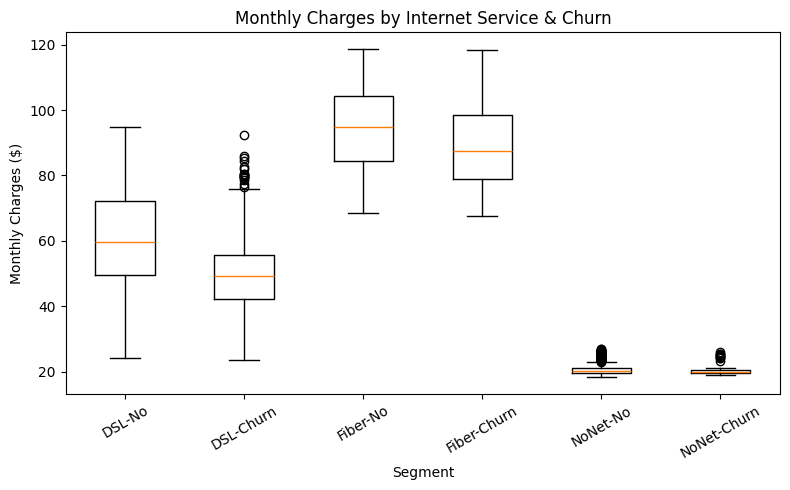

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Grupları tek tek veriyoruz
data = [
    df[(df["InternetService"]=="DSL") & (df["Churn"]==0)]["MonthlyCharges"],
    df[(df["InternetService"]=="DSL") & (df["Churn"]==1)]["MonthlyCharges"],
    
    df[(df["InternetService"]=="Fiber optic") & (df["Churn"]==0)]["MonthlyCharges"],
    df[(df["InternetService"]=="Fiber optic") & (df["Churn"]==1)]["MonthlyCharges"],
    
    df[(df["InternetService"]=="No") & (df["Churn"]==0)]["MonthlyCharges"],
    df[(df["InternetService"]=="No") & (df["Churn"]==1)]["MonthlyCharges"],
]

labels = [
    "DSL-No", "DSL-Churn",
    "Fiber-No", "Fiber-Churn",
    "NoNet-No", "NoNet-Churn"
]

plt.boxplot(data, labels=labels)

plt.title("Monthly Charges by Internet Service & Churn")
plt.xlabel("Segment")
plt.ylabel("Monthly Charges ($)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / "internet_churn_price_boxplot.png")
plt.show()

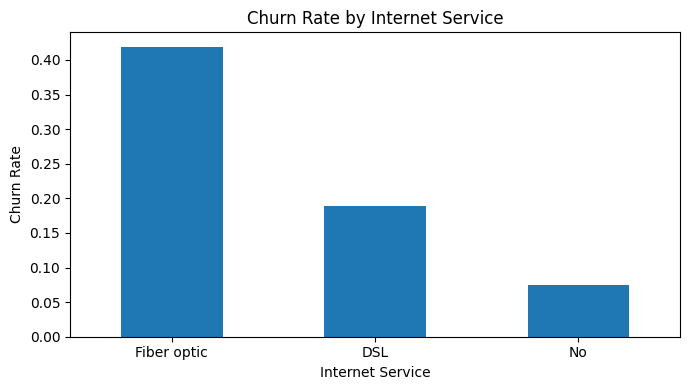

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

In [19]:
plt.figure(figsize=(7, 4))

internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "churn_by_internet_service.png")
plt.show()

internet_churn

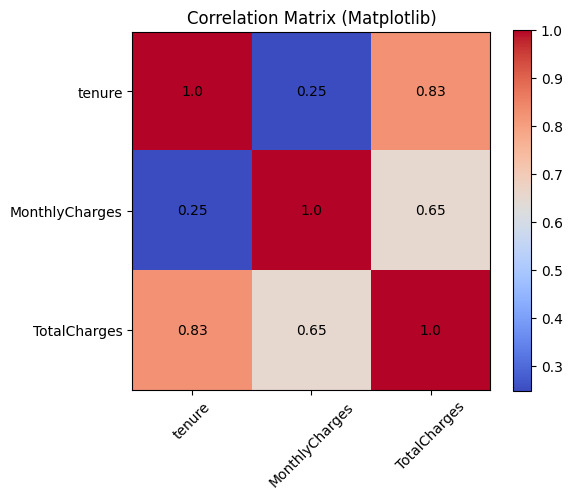

In [18]:
plt.figure(figsize=(6, 5))

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[numeric_cols].corr()

# heatmap çizimi
plt.imshow(corr, cmap="coolwarm")

# renk skalası
plt.colorbar()

# axis isimleri
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# değerleri hücre içine yaz
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix (Matplotlib)")

plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix_matplotlib.png")

plt.show()

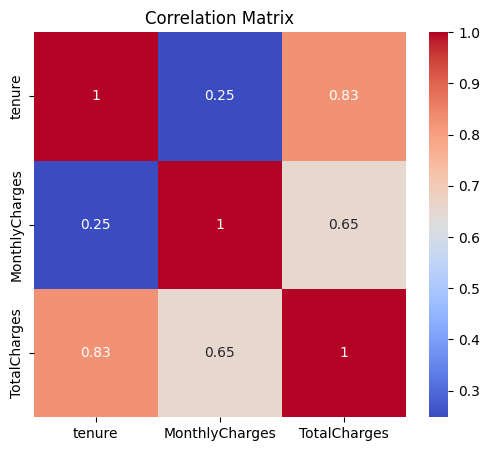

In [17]:
import seaborn as sns

plt.figure(figsize=(6,5))

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.savefig(FIG_DIR / "correlation_matrix.png")

plt.show()

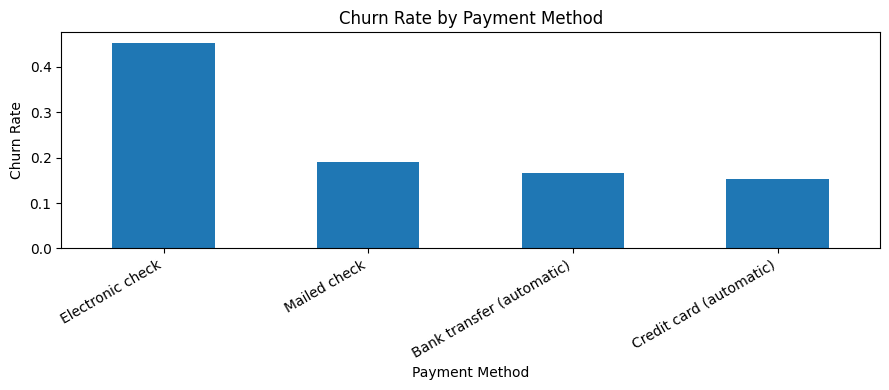

In [13]:
plt.figure(figsize=(9, 4))

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(FIG_DIR / "churn_by_payment_method.png")

plt.show()

<Figure size 600x400 with 0 Axes>

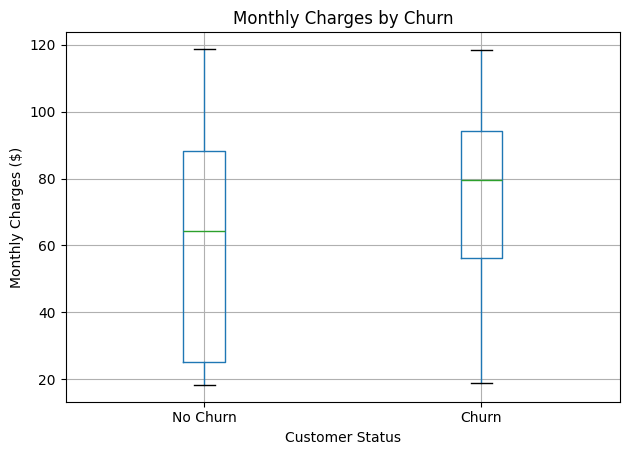

In [12]:
plt.figure(figsize=(6, 4))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")  # üstte çıkan gereksiz başlığı kaldırır

plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

plt.xticks([1, 2], ["No Churn", "Churn"])

plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_charges_boxplot.png")

plt.show()

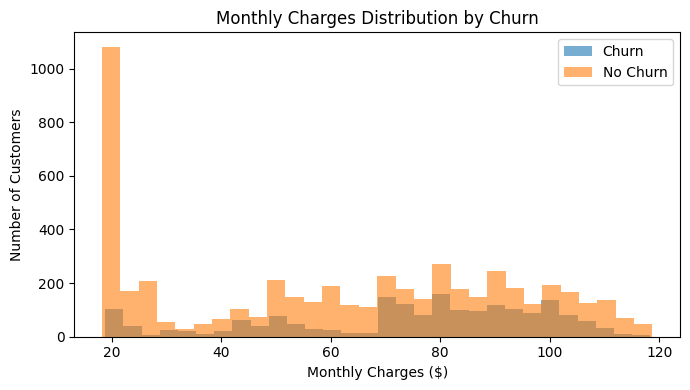

In [ ]:
plt.figure(figsize=(6, 4))


df[df["Churn"] == 1]["MonthlyCharges"].plot(
    kind="hist", bins=30, alpha=0.6, label="Churn"
)
df[df["Churn"] == 0]["MonthlyCharges"].plot(
    kind="hist", bins=30, alpha=0.6, label="No Churn"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_charges_by_churn.png")

plt.show()

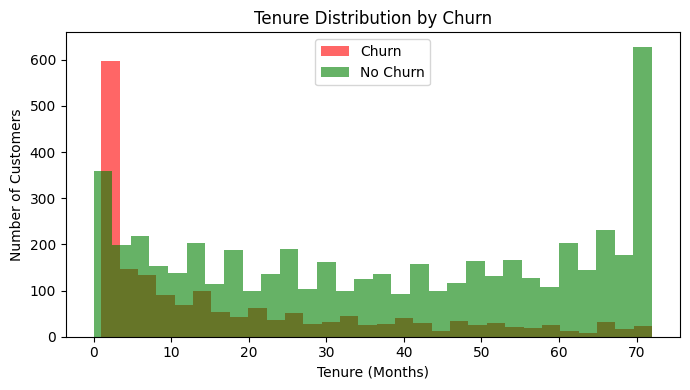

In [10]:
plt.figure(figsize=(7,4))

plt.hist(df[df["Churn"]==1]["tenure"], bins=30, alpha=0.6, label="Churn", color="red")
plt.hist(df[df["Churn"]==0]["tenure"], bins=30, alpha=0.6, label="No Churn", color="green")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "tenure_by_churn.png")

plt.show()

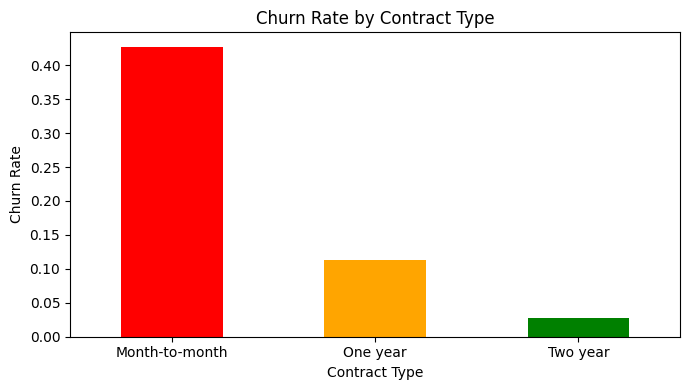

In [8]:
plt.figure(figsize=(7, 4))

contract_churn = df.groupby("Contract")["Churn"].mean()

contract_churn.sort_values(ascending=False).plot(kind="bar", color=["red", "orange", "green"])

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "churn_by_contract.png")

plt.show()

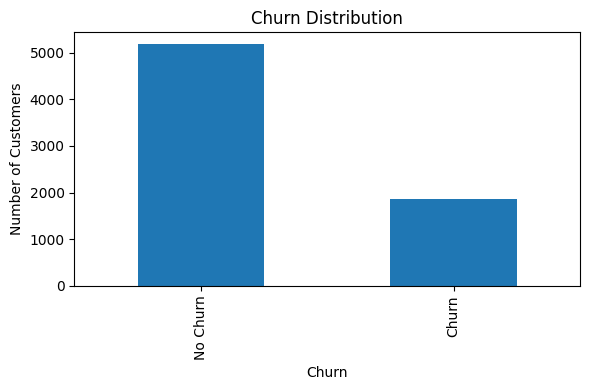

In [6]:
plt.figure(figsize=(6, 4))  

df["Churn"].value_counts().plot(kind="bar")

plt.xticks([0,1], ["No Churn", "Churn"])

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()  # kesilmeleri önler
plt.savefig(FIG_DIR / "churn_distribution.png")

plt.show()  # ekranda gösterir

In [4]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent   

DATA_PATH = BASE_DIR / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
FIG_DIR = BASE_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})